# PCA and Clustering Assignment

In [1]:
# Import the required libraries
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import sys
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.spatial import distance
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



sys.path.append('functions')

from pca_plots import (plot_explained_variance, plot_cos2_heatmap, plot_corr_cos, plot_cos2_bars,
                       plot_proportional_contributions, plot_pca_scatter, plot_pca_scatter_with_vectors,
                       plot_pca_scatter_with_categories)

## 0. Initial data exploration

In [2]:
# Load the penguins dataset
penguins = sns.load_dataset('penguins')

# Show the first rows of the dataset
print("First rows of the dataset:")
penguins.head()

First rows of the dataset:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
# Show basic information about the dataset
print("\nDataset information:")
penguins.info()


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [4]:
# Show descriptive statistics
desc_stats = penguins.describe().T
desc_stats

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


We inspect the rows with NaNs so we can handle them before moving on to PCA

In [5]:

penguins[penguins.isna().any(axis=1)]


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


We drop the observations with NaNs. At first, the idea was to drop only the rows with more than 50% missing values, but since it is hard to impute a column like sex, we decided to drop every row containing NaNs. 

In [6]:
penguins = penguins.dropna(axis=0)

We reset the index so the observations are ordered

In [7]:
penguins = penguins.reset_index(drop=True)


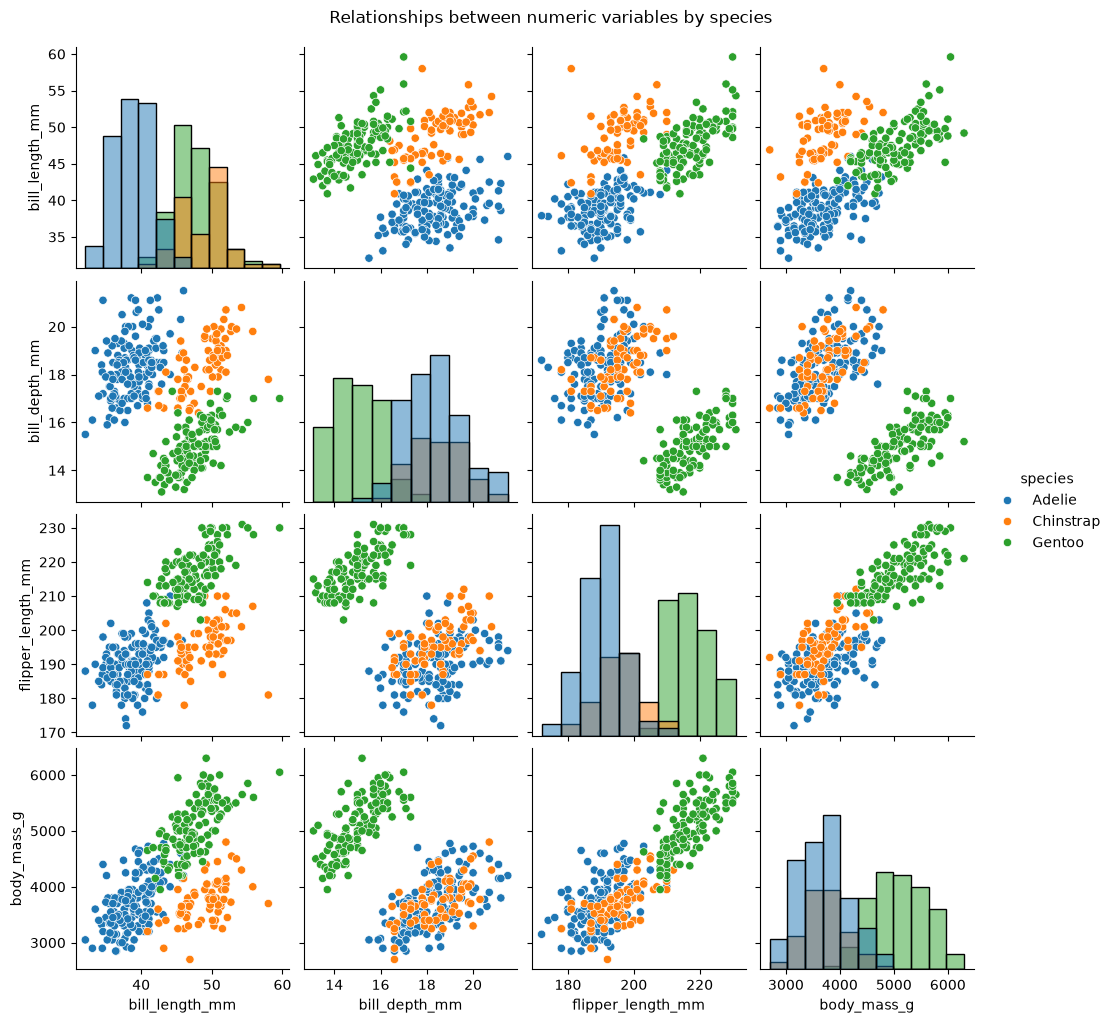

In [8]:
# Create a set of scatter plots (pairplot)
sns.pairplot(penguins, hue="species", diag_kind="hist")
plt.suptitle("Relationships between numeric variables by species", y=1.02)
plt.show()

In this set of scatter plots, we can observe the relationship between the numeric variables and how clusters or groupings emerge depending on the penguin species.

We also see histograms representing the frequencies of each numeric variable.

In this case, the data is being visualized with respect to species (a categorical variable). We could also visualize it with respect to the other two categorical variables: island and sex

Next, we visualize the relationship between two categorical variables: species and island. We can see how the Adelie species is present on every island, while each of the other two species is present on a different single island.

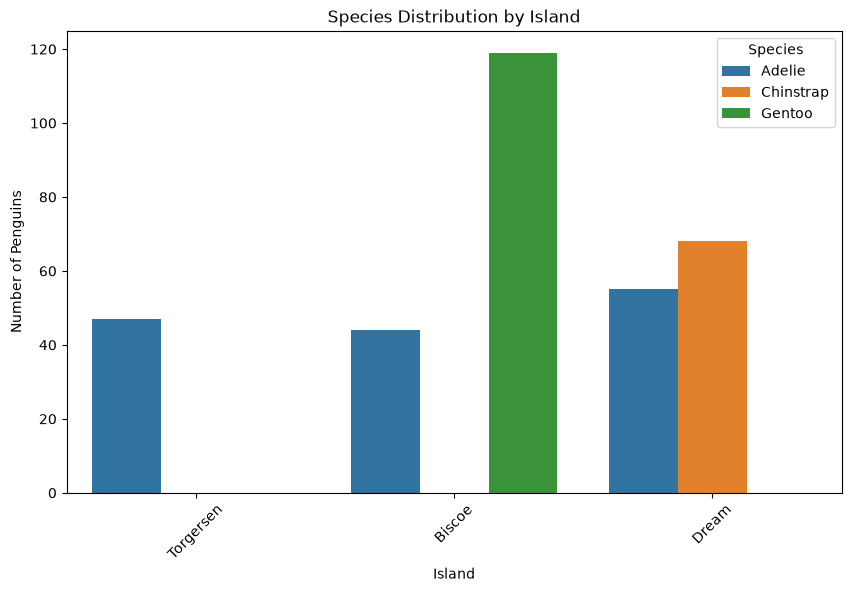

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=penguins, x='island', hue='species')
plt.title('Species Distribution by Island')
plt.xlabel('Island')
plt.ylabel('Number of Penguins')
plt.xticks(rotation=45)
plt.legend(title='Species')
plt.show()

## 1. Correlation matrix and graphical representation

When preparing the data for PCA, we must remove the categorical variables from the study. 

In [10]:
input_variables = list(penguins.columns)

# Select the numeric variables
numeric_input = penguins.select_dtypes(include = ['int', 'int32', 'int64','float', 'float32', 'float64']).columns

# Select the categorical variables
categorical_input = [variable for variable in input_variables if variable not in numeric_input]

In [11]:
penguins_num = penguins[numeric_input]

We also need to standardize the variables. It is not required for the correlation matrix (since it already works on standardized data), but it is for the remaining PCA steps. We leave it done:


In [12]:
scaler = StandardScaler()
penguins_num_Z = pd.DataFrame(scaler.fit_transform(penguins_num), columns=penguins_num.columns)

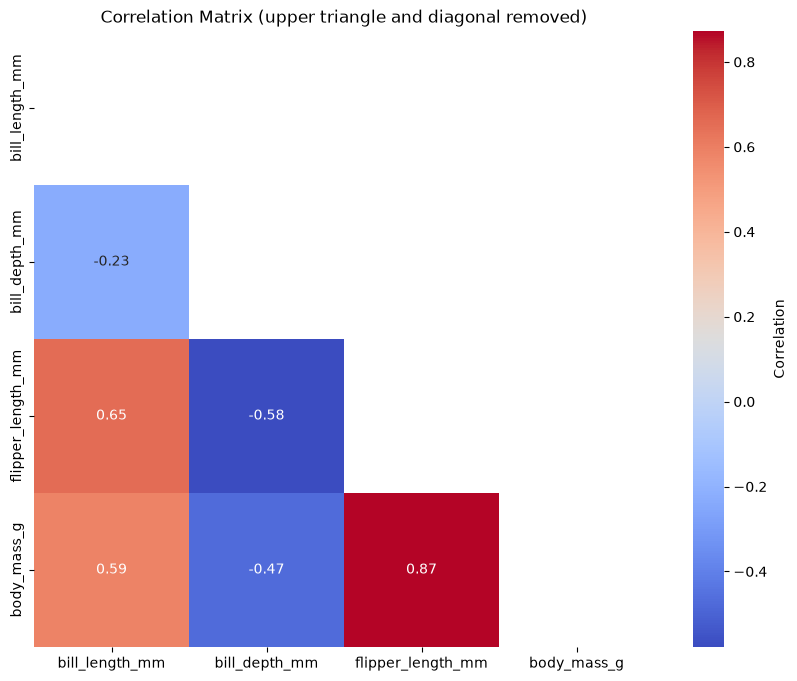

In [13]:
# Compute the correlation matrix (Pearson by default)
corr = penguins_num_Z.corr()

# Create a mask for the upper triangle (including the diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Apply the mask: the upper triangle and the diagonal are set to NaN
corr_lower = corr.mask(mask)

# Visualize the resulting matrix with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_lower, annot=True, cmap="coolwarm", cbar_kws={'label': 'Correlation'})
plt.title("Correlation Matrix (upper triangle and diagonal removed)")
plt.show()

Thanks to the correlation matrix, we can see the presence of multicollinearity among the variables. On the one hand, there is a strong direct relationship between body mass in grams and flipper length in mm. On the other hand, the strongest inverse correlation appears between bill depth and flipper length.

In short, this is an ideal scenario for applying Principal Component Analysis

## 2. Principal component analysis 

First, we fit the PCA model with 4 principal components, i.e. the maximum allowed for this dataset since that is its number of columns. The goal is to find out how many components we need to explain as much of the dataset's variability as possible

In [14]:
pca = PCA(n_components=4)

In [15]:
fit = pca.fit(penguins_num_Z)

In [16]:
eigenvalues = fit.explained_variance_
explained_var = fit.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

In [17]:
data = { "Eigenvalues": eigenvalues , "Explained Variance": explained_var
, "Cumulative Variance": cumulative_var}
table = pd.DataFrame(data, index=["Component {}".format(i) for i in range
(1, fit.n_components_ +1)])

In [18]:
table

,Eigenvalues,Explained Variance,Cumulative Variance
Component 1,2.753625,0.686339,0.686339
Component 2,0.780461,0.194529,0.880868
Component 3,0.369753,0.092161,0.973029
Component 4,0.108210,0.026971,1.000000


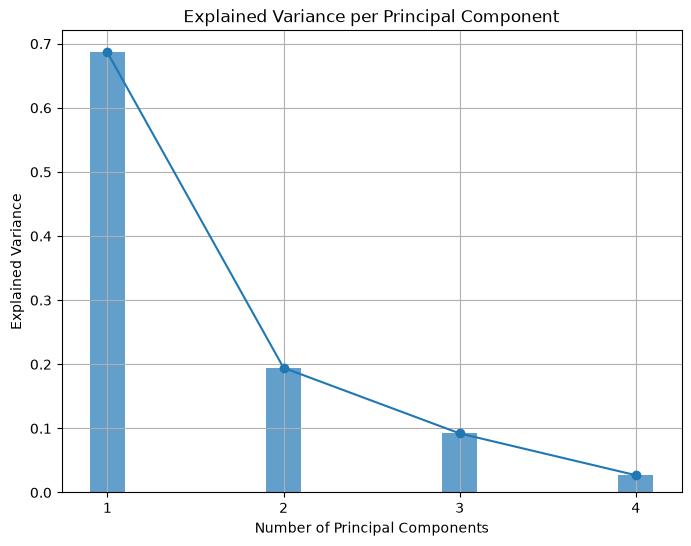

In [19]:
plot_explained_variance(explained_var, fit.n_components_)

The results show that 68% of the variability is explained by the first component and 19% by the second. Since the two together already cover 88% of the variability, these components were selected as the optimal ones. However, it would not be a bad idea to also select the third one, reaching 97%.




## 3. PCA with the optimal number of components
As specified in the previous section, we decided to continue with 2 principal components. Therefore, we fit the model with that number and obtain the eigenvectors

In [20]:
pca = PCA(n_components=2)
fit = pca.fit(penguins_num_Z)

eigenvectors = pd.DataFrame(pca.components_.T,
                            columns = ['Eigenvector of PC {}'.format(i) for i in range(1, fit.n_components_+1)],
                            index = ['{}_z'.format(variable) for variable in numeric_input])

eigenvectors       

,Eigenvector of PC 1,Eigenvector of PC 2
bill_length_mm_z,0.453753,0.600195
bill_depth_mm_z,-0.399047,0.796170
flipper_length_mm_z,0.576825,0.005788
body_mass_g_z,0.549675,0.076464


What we see above is the eigenvector matrix used to map the data matrix into the principal component space

Next, we compute this representation of the data in the principal component space (that is, the principal components themselves). Instead of only fitting the dataset (to obtain eigenvalues and eigenvectors), we use fit.transform to transform it.



In [21]:
# Compute the first two principal components for each observation
pca_results = pd.DataFrame(fit.transform(penguins_num_Z),
                           columns=['Component {}'.format(i) for i in range(1, fit.n_components_+1)],
                           index=penguins_num_Z.index)

And we add them to the standardized dataframe to compute the correlation between the principal components and the original columns

In [22]:
# Add the principal components to the standardized dataset.
penguins_z_pc = pd.concat([penguins_num_Z, pca_results], axis=1)
display(penguins_z_pc)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,Component 1,Component 2
0,-0.896042,0.780732,-1.426752,-0.568475,-1.853593,0.032069
1,-0.822788,0.119584,-1.069474,-0.506286,-1.316254,-0.443527
2,-0.676280,0.424729,-0.426373,-1.190361,-1.376605,-0.161230
3,-1.335566,1.085877,-0.569284,-0.941606,-1.885288,-0.012351
4,-0.859415,1.747026,-0.783651,-0.692852,-1.919981,0.817598
...,...,...,...,...,...,...
328,0.587352,-1.762145,0.931283,0.892957,1.997716,-0.976771
329,0.514098,-1.457000,1.002739,0.799674,1.832651,-0.784510
330,1.173384,-0.744994,1.502928,1.919069,2.751505,0.266556
331,0.221082,-1.202712,0.788372,1.234995,1.713854,-0.725875


Now we obtain the correlations between the dataset columns and the principal components. We also compute the squared cosine metric to see the percentage of each variable explained by each component.

In [23]:
# Store the variable names of the combined dataset (variables and components).
all_variables = penguins_z_pc.columns

# Compute the correlations and select the ones of interest (variables vs. components).
# We compare the standardized dataframe against the principal components. That is why these datasets are used instead of penguins_z_pc
correlation = pd.DataFrame(np.corrcoef(penguins_num_Z.T, pca_results.T),

                           index = all_variables, columns = all_variables)

n_variables = fit.n_features_in_
correlations_with_pcs = correlation.iloc[:fit.n_features_in_, fit.n_features_in_:]
display(correlations_with_pcs)

,Component 1,Component 2
bill_length_mm,0.751829,0.529438
bill_depth_mm,-0.661186,0.702309
flipper_length_mm,0.955748,0.005106
body_mass_g,0.910762,0.067449


In [24]:
cos2 = correlations_with_pcs**2
cos2

,Component 1,Component 2
bill_length_mm,0.565247,0.280304
bill_depth_mm,0.437167,0.493237
flipper_length_mm,0.913454,0.000026
body_mass_g,0.829488,0.004549


#### Section 3a

We can see how Component 1, although it captures information from every variable, explains the variables related to flipper length and body mass almost entirely.

On the other hand, these two variables are barely represented in Component 2. This component seems to explain most of the remaining variability of the bill characteristics. 

The following plots show the results in a more visual way

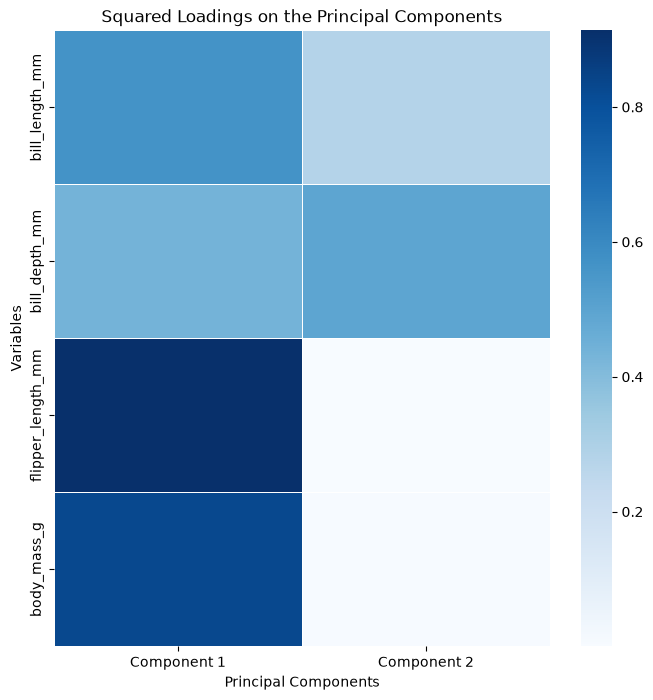

In [25]:
plot_cos2_heatmap(cos2)

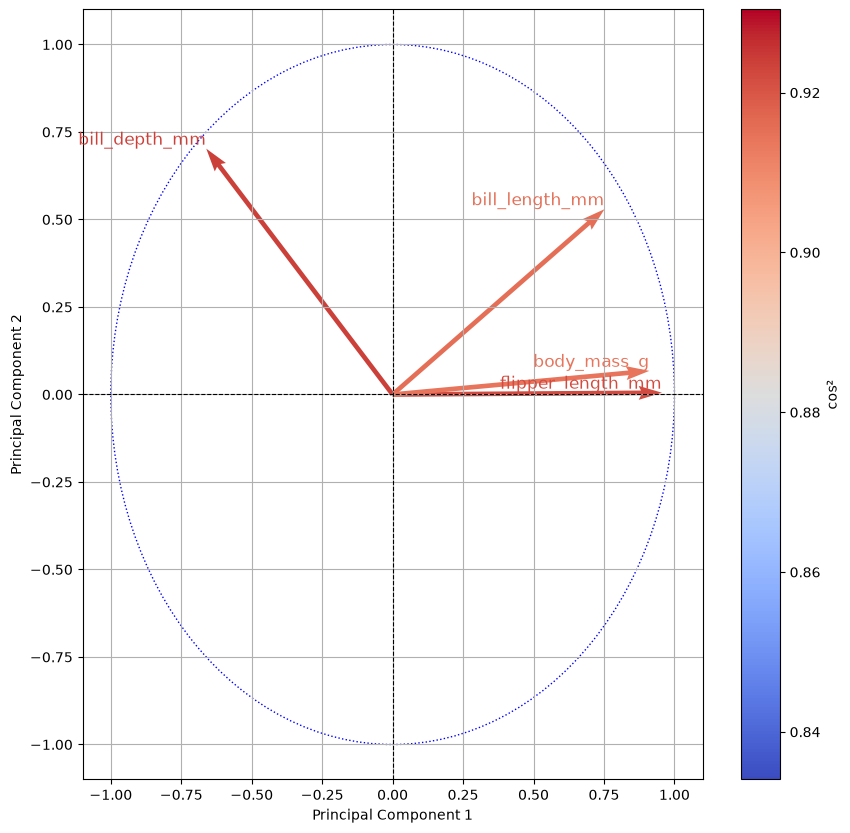

In [26]:
plot_corr_cos(fit.n_components, correlations_with_pcs)

### Section 3b
Next, we look at the coordinates of the penguins in the new principal component space. The axes are the components and the points are the penguin observations. We also differentiate them by species to answer the question of this section: which species stand out the most in each component?

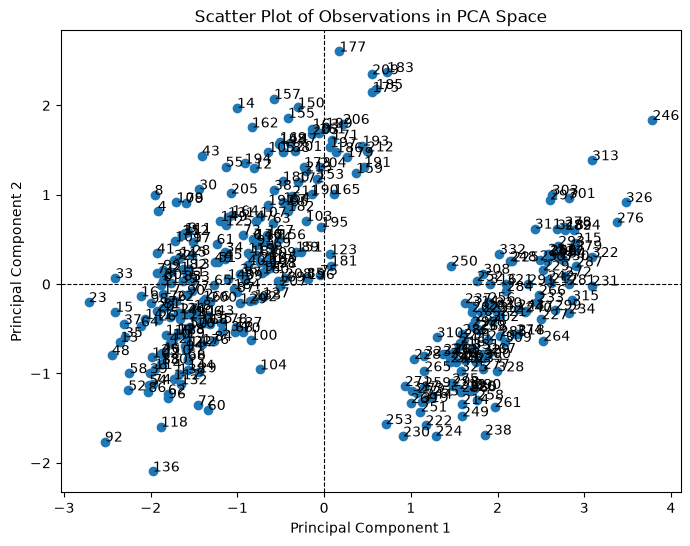

In [27]:
plot_pca_scatter(pca, penguins_num_Z, fit.n_components)

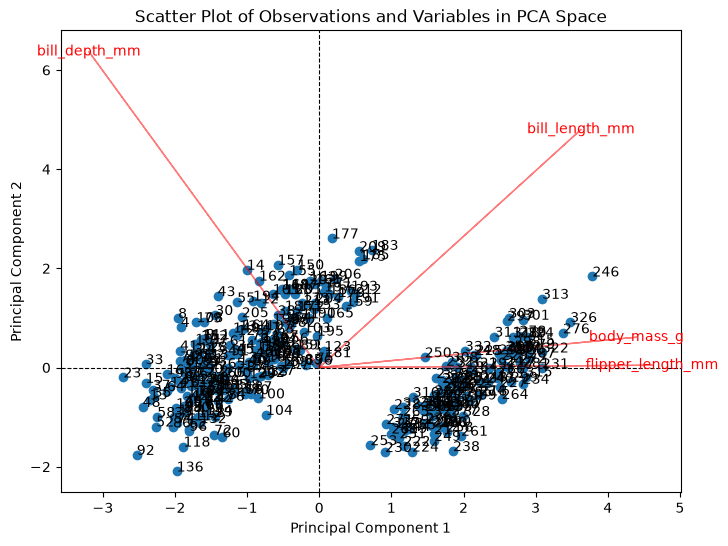

In [28]:
plot_pca_scatter_with_vectors(pca, penguins_num_Z, fit.n_components, fit.components_)

In [29]:
# Add the categorical variable "species" to the data
penguins_num_categ_z = pd.concat([penguins_z_pc, penguins["species"]], axis=1)


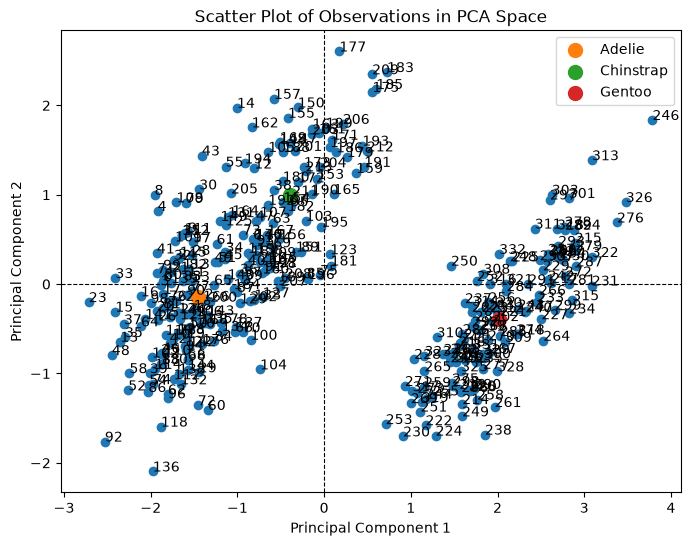

In [30]:
plot_pca_scatter_with_categories(penguins_num_categ_z, pca_results , fit.n_components, "species")

Looking at the plots, we can see how the Gentoo species stands out far more than the other two in Component 2, which is more related to body mass and flipper length.

Regarding Principal Component 1, the species that stands out the most is Chinstrap. This component captured information from all 4 measurements in general

### Section 3c
We can build an index from the first principal component. This component captures the largest possible share of variability, drawing on all the numeric variables of the dataframe.




To do so, we can group by species and compute the mean value of Component 1 for each of them.

In [31]:
# Compute the index: mean value of PC1 for each species
index_by_species = penguins_num_categ_z.groupby('species')['Component 1'].mean()
index_by_species

species
Adelie      -1.459721
Chinstrap   -0.388600
Gentoo       2.012976
Name: Component 1, dtype: float64

The resulting index lets us differentiate each species quite well. The index for Adelie is very negative and different from the Gentoo one. This reflects the large difference and distance between their centroids in the principal component space. Then, the Chinstrap species has an index in between the two, matching its position in the component space.

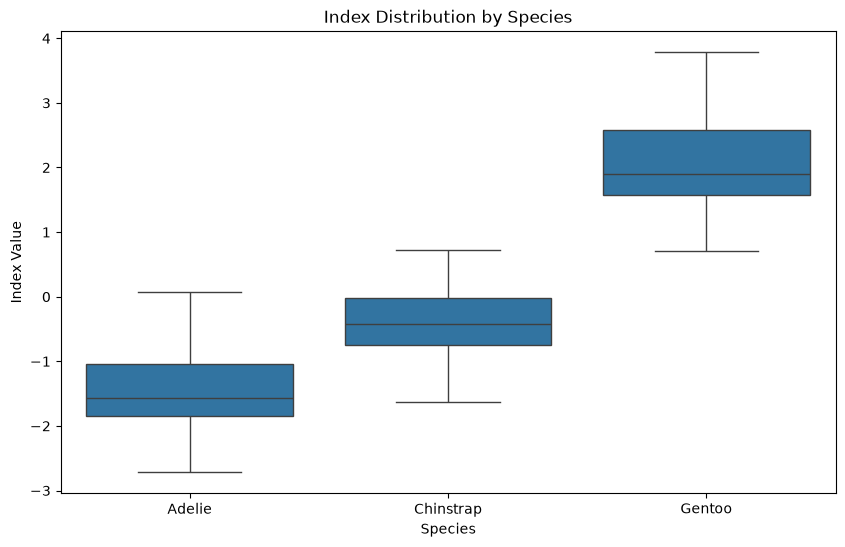

In [32]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=penguins_num_categ_z, x='species', y='Component 1')
plt.title('Index Distribution by Species')
plt.xlabel('Species')
plt.ylabel('Index Value')
plt.show()

If we look at the centroid plot from section 3b, we could not pick Principal Component 2, since the values of the Adelie and Gentoo species would be very close. Using Component 1 they are further apart, which yields the index above.

## 4. Determining the number of clusters. Hierarchical method

In [33]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


First, we need to preprocess the data by transforming:
- the numeric variables, standardizing them
- the categorical variables, converting them into dummies

In [34]:
# Select the numeric and categorical variables
numeric_input = penguins.select_dtypes(include = ['int', 'int32', 'int64','float', 'float32', 'float64']).columns
categorical_input = [variable for variable in penguins.columns if variable not in numeric_input]

# Create a ColumnTransformer object
encoder = OneHotEncoder(drop='first')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_input),
        ('cat', encoder, categorical_input)
    ])

# Fit and transform the data
penguins_prep = preprocessor.fit_transform(penguins)

In [35]:

# Calculate the pairwise Euclidean distances
distance_matrix = distance.cdist(penguins_prep, penguins_prep, 'euclidean')


Despite the large number of observations, which makes the figure harder to read, we can make out about 3 groups. We start getting a sense of the optimal k we will obtain from the dendrogram

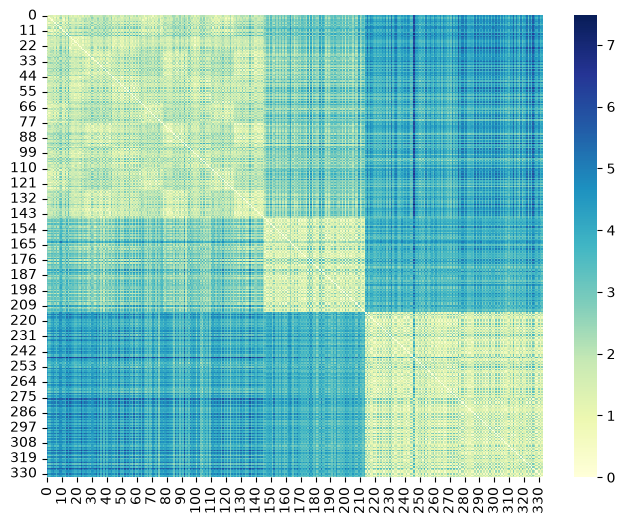

In [36]:
plt.figure(figsize=(8, 6))
df_std_distance = pd.DataFrame(distance_matrix, index = penguins.index, columns = penguins.index)
sns.heatmap(df_std_distance, annot=False, cmap="YlGnBu", fmt=".1f")
plt.show()

/var/folders/dn/34jchd552_q2z2hw65lgv2y80000gn/T/ipykernel_73870/3840624230.py:2: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(df_std_distance, method='ward')


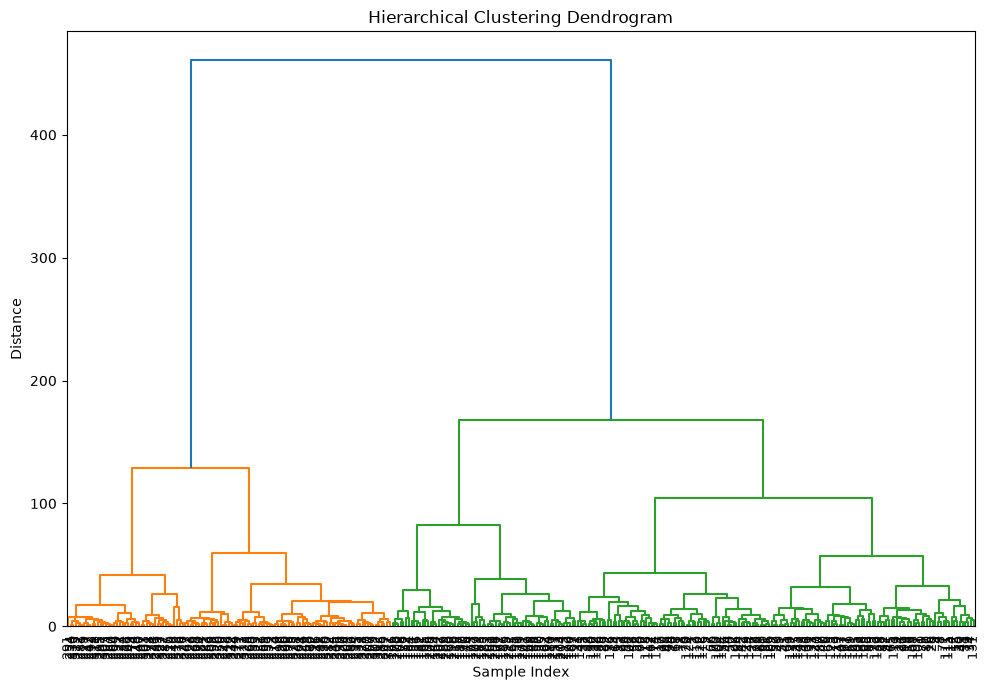

In [37]:

# Calculate the linkage matrix
linkage_matrix = sch.linkage(df_std_distance, method='ward')

# Create the dendrogram
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(
    linkage_matrix,
    labels=penguins.index,
    leaf_font_size=9,
    leaf_rotation=90
)

# Add title and adjust layout
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Looking at the dendrogram, we can see 2 clearly differentiated groups. This was also visible in the PCA. In addition, there is a further subdivision into 3 or 4 clusters. In other words, we could start from k=3 or k=4.

Given the extra information provided by the visual representation of the distance matrix, we decided to proceed with k=3. 

## 5. K-means clustering (non-hierarchical method)

Now that we know a likely optimal k, it is time to obtain the resulting groups

In [38]:

# Set the number of clusters (k=3)
k = 3

# Initialize the KMeans model
kmeans = KMeans(n_clusters=k, random_state=0)

# Fit the KMeans model to your standardized data
kmeans.fit(penguins_prep)

# Get the cluster labels for your data
kmeans_cluster_labels = kmeans.labels_

print(kmeans_cluster_labels)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


After obtaining the clustering labels, we reduce the dimensions to a 2D space to visualize the groupings

In [39]:
from sklearn.decomposition import PCA

# Assuming 'df' is your original DataFrame with data
# 'cluster_assignments' contains cluster assignments

# Step 1: Perform PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(penguins_prep)

# Create a new DataFrame for the 2D principal components
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

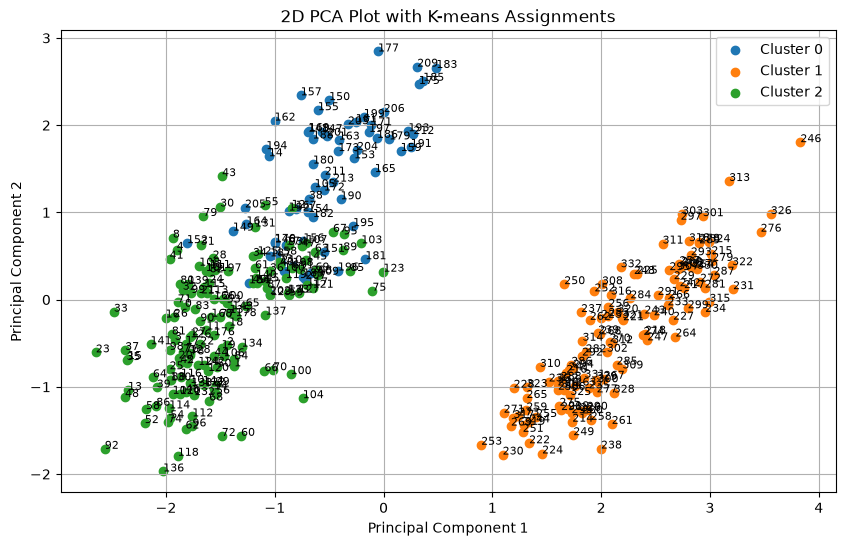

In [40]:
# Step 2: Create a scatter plot with colors for clusters
plt.figure(figsize=(10, 6))

# Loop through unique cluster assignments and plot data points with the same color
for cluster in np.unique(kmeans_cluster_labels):
    plt.scatter(df_pca.loc[kmeans_cluster_labels == cluster, 'PC1'],
                df_pca.loc[kmeans_cluster_labels == cluster, 'PC2'],
                label=f'Cluster {cluster}')
# Add labels to data points
for i, row in df_pca.iterrows():
    plt.text(row['PC1'], row['PC2'], str(penguins.index[i]), fontsize=8)

plt.title("2D PCA Plot with K-means Assignments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

As we can see, the clustering produced a total of 3 fairly well differentiated groups. We now apply the elbow method to check whether k=3 is optimal or a better value exists.

In [41]:
#Create an array to store the WCSS values for different values of K:
wcss = []

for k in range(1, 11):  # You can choose a different range of K values
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(penguins_prep)
    wcss.append(kmeans.inertia_)  # Inertia is the WCSS value

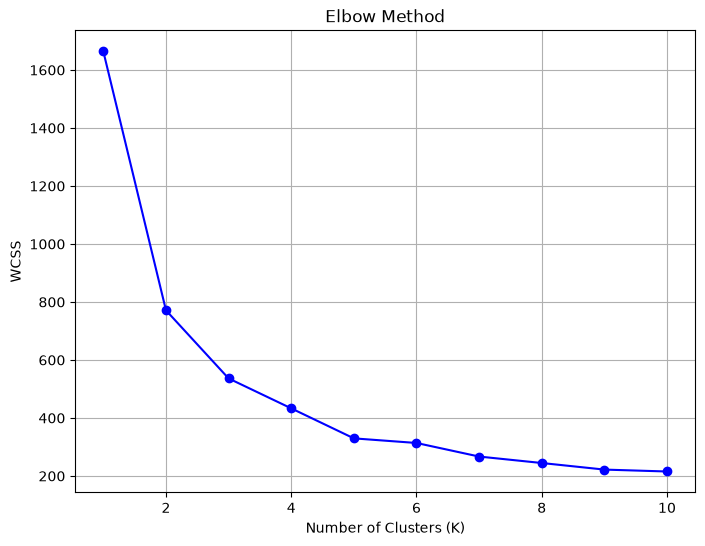

In [42]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

The elbow method shows that the main drop in the WCSS value happens within the first 3 clusters. We could stretch it to 5 clusters, but beyond that point increasing the number of clusters is not worth it.

Let's try k = 5

In [43]:
# Set the number of clusters (k=5)
k = 5

# Initialize the KMeans model
kmeans = KMeans(n_clusters=k, random_state=0)

# Fit the KMeans model to your standardized data
kmeans.fit(penguins_prep)

# Get the cluster labels for your data
kmeans_cluster_labels = kmeans.labels_

print(kmeans_cluster_labels)

[3 2 2 2 3 2 3 2 3 3 2 2 3 2 3 2 3 2 3 2 2 3 2 2 3 2 2 2 3 2 3 3 2 2 3 2 3
 2 3 2 3 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3
 2 3 2 3 2 3 3 2 3 2 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 3 3 2
 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 2 2 2 2 3 3 2 2 3 2 3 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 4 1 4 1 1 4 4 1
 4 1 4 1 4 1 4 1 4 1 4 1 1 4 4 1 4 1 1 4 1 1 4 4 1 4 1 4 1 4 1 4 1 4 1 1 4
 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 1 4 1 4 1 1 4 4 1 4 1 4 1 4 1 4 1
 4 1 4 1 4 1 4 1 4 1 4 1 1 4 4 1 4 1 4 1 1 4 1 4 1 4 1 4 1 4 1 1 4 4 1 4 1]


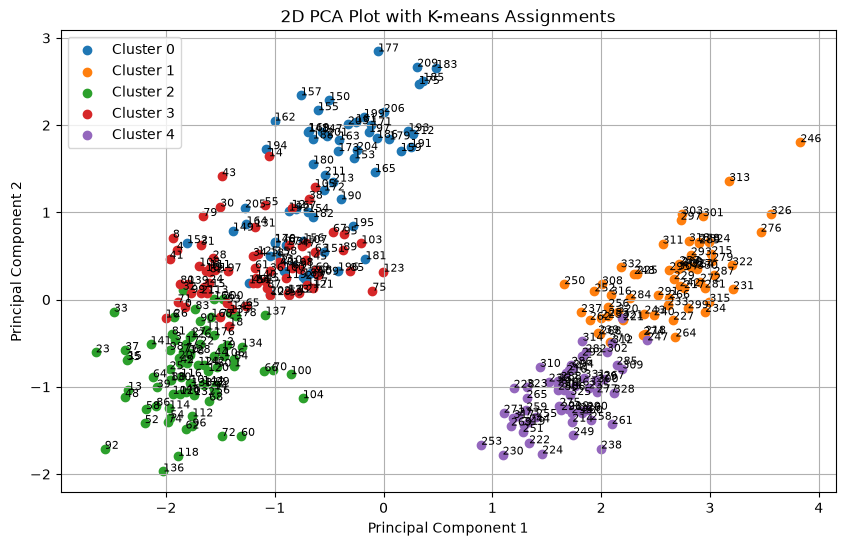

In [44]:
# Step 2: Create a scatter plot with colors for clusters
plt.figure(figsize=(10, 6))

# Loop through unique cluster assignments and plot data points with the same color
for cluster in np.unique(kmeans_cluster_labels):
    plt.scatter(df_pca.loc[kmeans_cluster_labels == cluster, 'PC1'],
                df_pca.loc[kmeans_cluster_labels == cluster, 'PC2'],
                label=f'Cluster {cluster}')
# Add labels to data points
for i, row in df_pca.iterrows():
    plt.text(row['PC1'], row['PC2'], str(penguins.index[i]), fontsize=8)

plt.title("2D PCA Plot with K-means Assignments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

It seems that k=5 is not a bad number of groups. However, clusters 3 and 0 overlap a lot, and adding 2 more groups is not worth it for these results.

Therefore, k=3 is taken as the optimal number of groups.

## 6. Evaluation: silhouette method

The silhouette method provides a validation of the chosen number of clusters. The silhouette score is a value between -1 and 1. A score close to 1 indicates that the observation matches its own group well and does not match the neighboring groups.

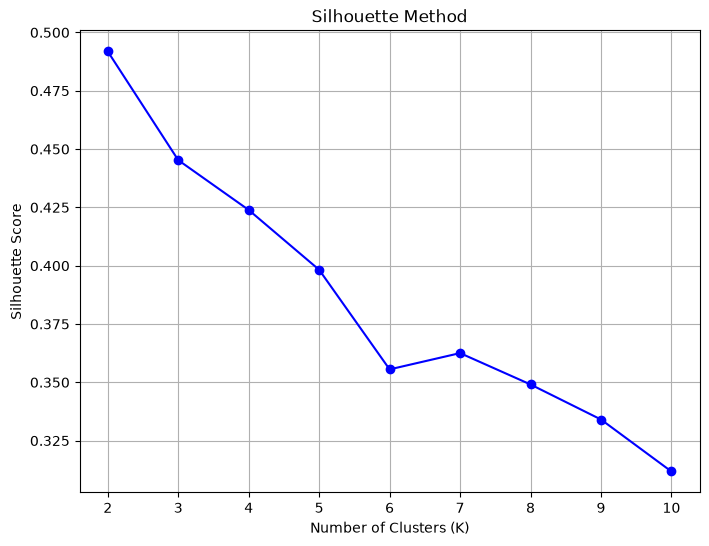

In [45]:
#Create an array to store silhouette scores for different values of K

silhouette_scores = []

#Run K-means clustering for a range of K values and calculate the silhouette score for each K:

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(penguins_prep)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(penguins_prep, labels)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='-', color='b')
plt.title('Silhouette Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In this case, k=2 seems to give the best result. However, that is a very simplistic grouping for this dataset. The next one is k = 3, which was the optimal number chosen.

Since the drop in the silhouette score continues for the following values of k, we can confirm that choosing k = 3 was a good choice and that increasing it further is not worth it. 

## 7. Comparison between Hierarchical and K-means

On the one hand, both methods identify groups that match the real species quite well.

Both manage to split the observations into 3 well-defined groups.

The differences are mostly theoretical. The hierarchical method of building a dendrogram does not require a predefined number of clusters to run. In fact, this method is usually used to get a sense of the number of clusters to choose.

Starting from that chosen number (though the elbow method could also be used), the K-means algorithm is applied to obtain the final group division, i.e. the labels that classify the observations.

In short, both algorithms are two parts of a process whose goal is to find the optimal group division for the dataset under study

## 8. Interpretation of the groups.
What do the identified groups represent in the context of the penguin species? Are there significant patterns or trends?

The groups represent exactly the penguin species. If we compare the PCA and clustering results, we can see how the species centroids are defined by the cluster groups. That is,
cluster 0 corresponds to the Chinstrap species, cluster 1 to Gentoo and cluster 2 to Adelie

So the species of the animal strongly influences the group it is classified into. The label could well be the species

## Summary of findings and conclusions. Limitations and challenges encountered during the clustering process.

As discussed in the previous section, principal component analysis and clustering led to the following result: the species has a very significant influence on how the observations are grouped.

During the clustering process, I faced the following challenge. I hesitated about whether to include the categorical variables in the study — that is, the species, the island and the sex of the animal. However, after a quick test with the code, removing the categorical columns, the result was very similar. In other words, even after removing categorical variables such as species, the group division remained the same.

Therefore, the information provided by the categorical variable species and by the numeric variables seems to be the same. That is, penguins of different species have different anatomical properties that make them distinct and therefore classified into different groups. 